In [1]:
import os
import json
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression
#Importing Regression models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.inspection import permutation_importance

if os.path.basename(os.getcwd()) == "analysis":
    os.chdir("../")
#from src.utilities import set_train_opts

In [2]:
data_path = "data/"
output_dir = "model"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [3]:
##the selected models have overall low error
##fit the central data point well in xc, yc, zc, plot
##have highest error in the lower right corner of xc, yc, zc, triangle
models = [
    ("Linear Regression", LinearRegression()),###fits wrongly, doesn't fit weel the middle point
   ("Random Forest Regression", RandomForestRegressor(max_depth=3, random_state=0)),### fits worse the right lower corner, and lower edge (confirm)
   ("Random Forest Regression1", RandomForestRegressor(max_depth=3, random_state=0)),
   ("Decision Tree Regressor" , DecisionTreeRegressor(max_depth=3, random_state=0)),
   ("Gradient Boosting Regression", GradientBoostingRegressor(random_state=0))###in agreement with random forest
    # ("Kernel Ridge Regression", KernelRidge())## ? also in agreement with random foreest. check how it works
]

In [7]:
select_cols=["rownum", "xA", "yA", "zA", "xC", "yC", "zC", "rA", "rB", "rC", "TF", "Eg", "duplicated"]
df = pd.read_csv(data_path+"prepared_data_Sona.csv")[select_cols]
df.head()
df.dropna(inplace=True)

In [8]:
df.tail()

,rownum,xA,yA,zA,xC,yC,zC,rA,rB,rC,TF,Eg,duplicated
111,122.0,0.0,1.0,0.0,0.000,1.000,0.0,2.16,1.19,1.96000,0.924851,2.30,0
112,123.0,0.0,1.0,0.0,0.333,0.667,0.0,2.16,1.19,1.91005,0.928359,2.50,0
113,124.0,0.0,1.0,0.0,0.500,0.500,0.0,2.16,1.19,1.88500,0.930162,2.65,0
114,125.0,0.0,1.0,0.0,0.667,0.333,0.0,2.16,1.19,1.85995,0.931994,2.75,0
115,126.0,0.0,1.0,0.0,1.000,0.000,0.0,2.16,1.19,1.81000,0.935738,3.10,0


In [9]:
train_cols = ["xA", "yA", "zA", "xC", "yC", "zC", "rA", "rB", "rC", "TF"]##,"rA"
target_col = "Eg"
X=df[train_cols]
y=df[target_col]
X_train_b, X_test_b, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print(len(X_train_b), len(X_test_b))

92 24


In [10]:
###correcting the test set. all the tri-element cases should be in test
test_def = df[(df["xC"]!=0)&(df["yC"]!=0)&(df["xC"]+df["yC"]<1)]
X_train_b = X_train_b.drop(labels=test_def.index)
y_train = y_train.drop(labels=test_def.index)
X_test_b = pd.concat([X_test_b, test_def[train_cols]])
y_test = pd.concat([y_test, test_def[target_col]])
print(len(X_train_b), len(X_test_b))

92 24


Performance of  Linear Regression
Mean error for train set: 0.021216720245688953
Median error for train set: 0.014189006301038793
Mean error for validation set: 0.03132093985884859
Median error for validation set: 0.024279809044765198
Model Linear Regression is saved in dir model/Linear_Regression
Performance of  Random Forest Regression
Mean error for train set: 0.018032653523253683
Median error for train set: 0.01142176193606386
Mean error for validation set: 0.026592843344091874
Median error for validation set: 0.024919001019687005
Model Random Forest Regression is saved in dir model/Random_Forest_Regression
Performance of  Random Forest Regression1
Mean error for train set: 0.018030657606449264
Median error for train set: 0.011702302586442264
Mean error for validation set: 0.02668106763772382
Median error for validation set: 0.02422409795510596
Model Random Forest Regression1 is saved in dir model/Random_Forest_Regression1
Performance of  Decision Tree Regressor
Mean error for trai

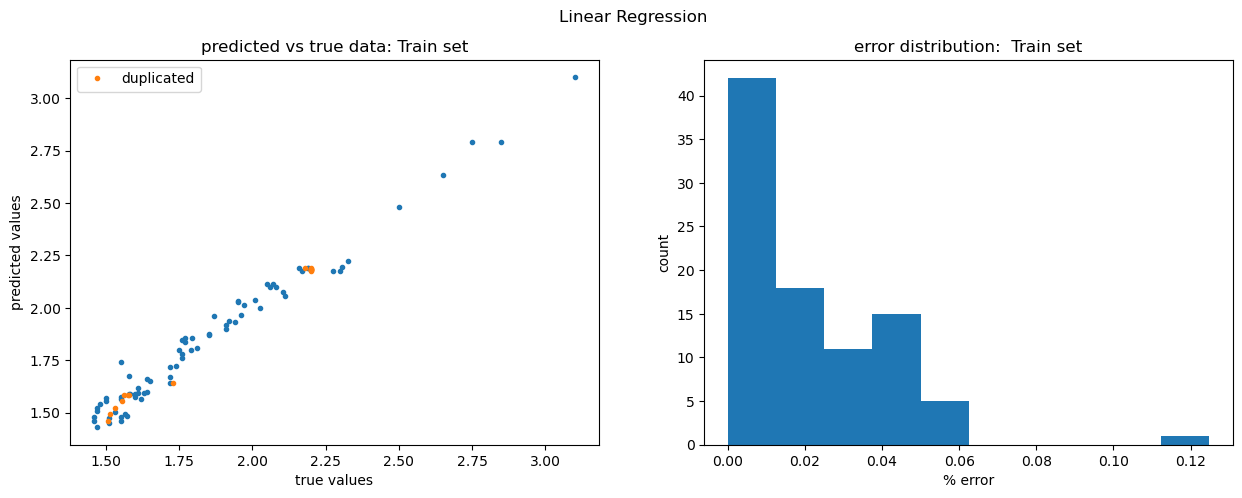

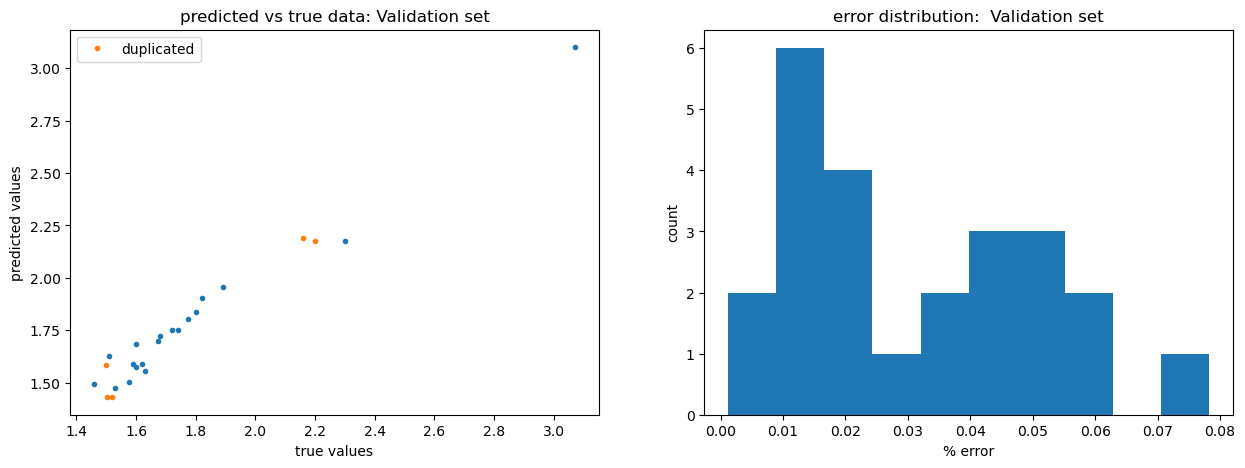

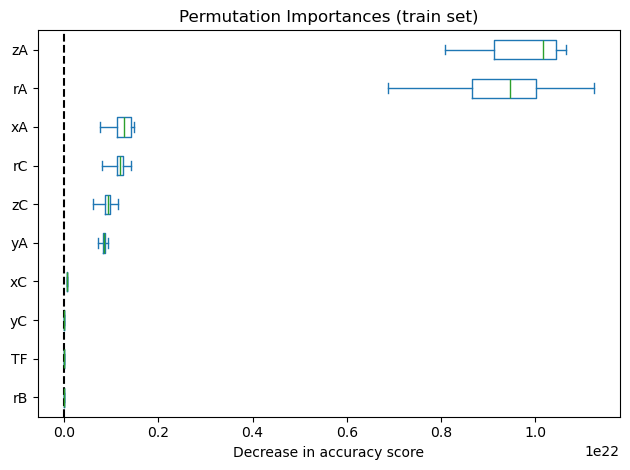

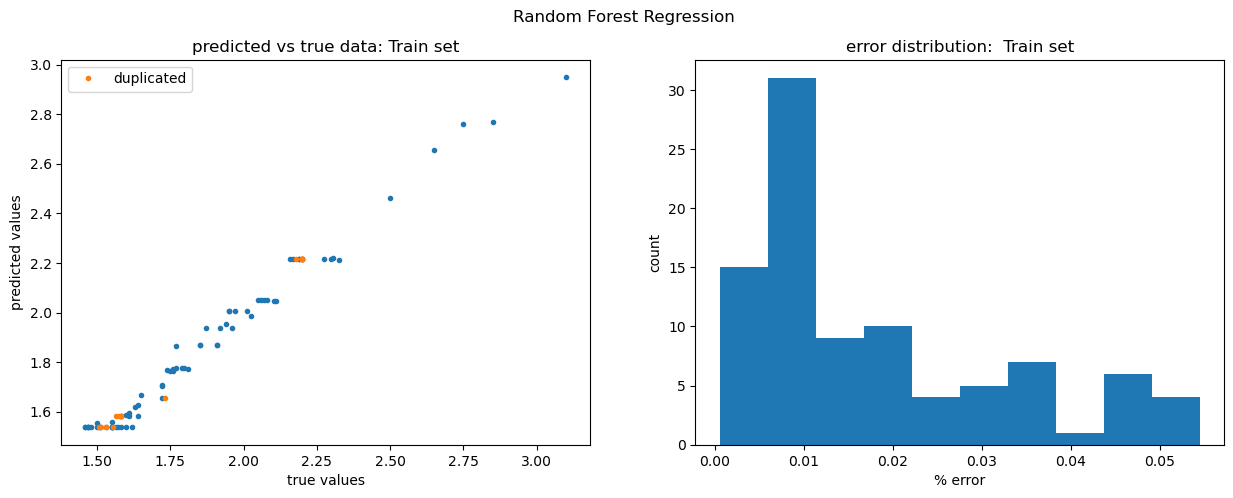

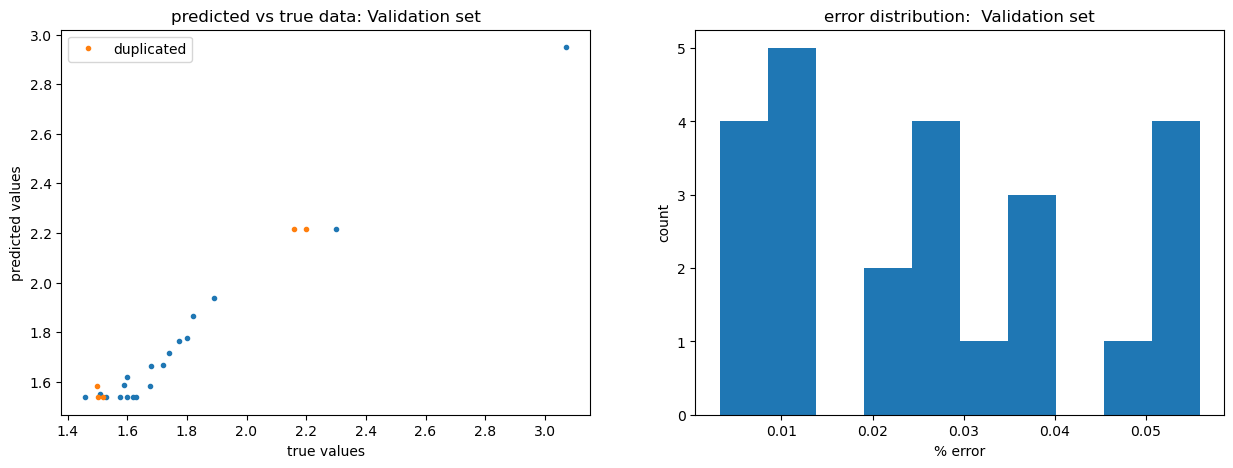

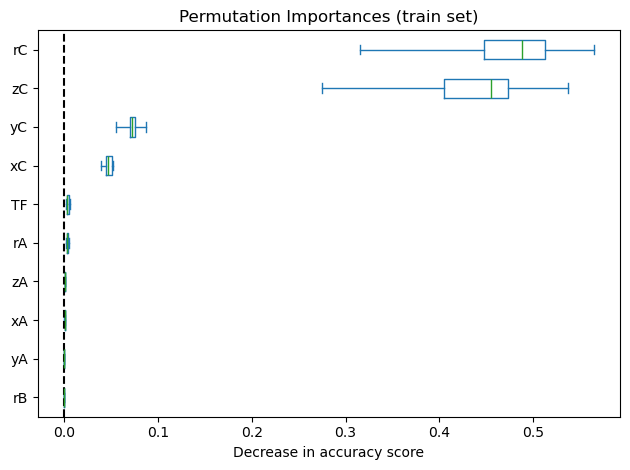

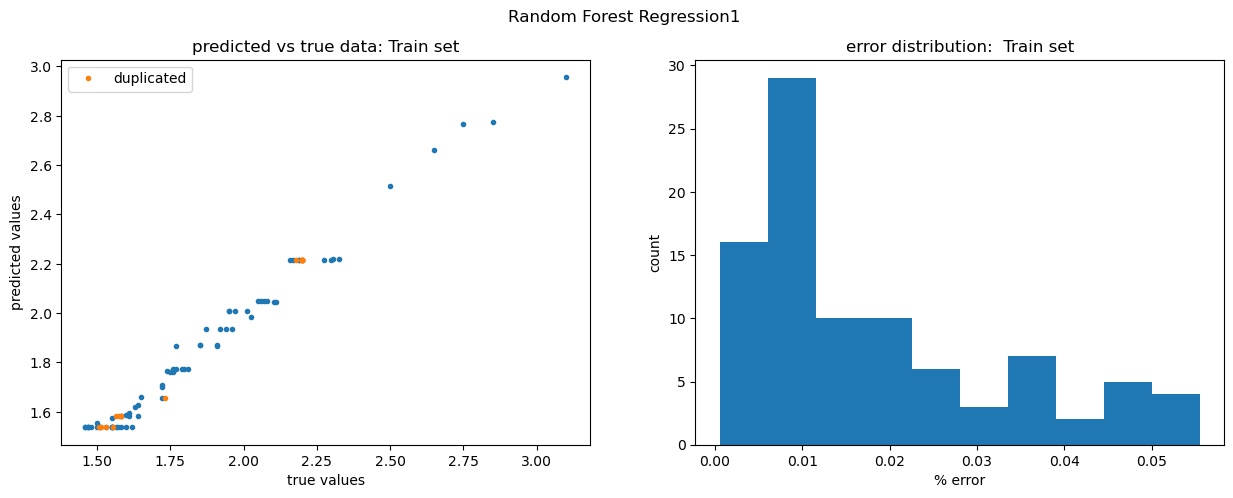

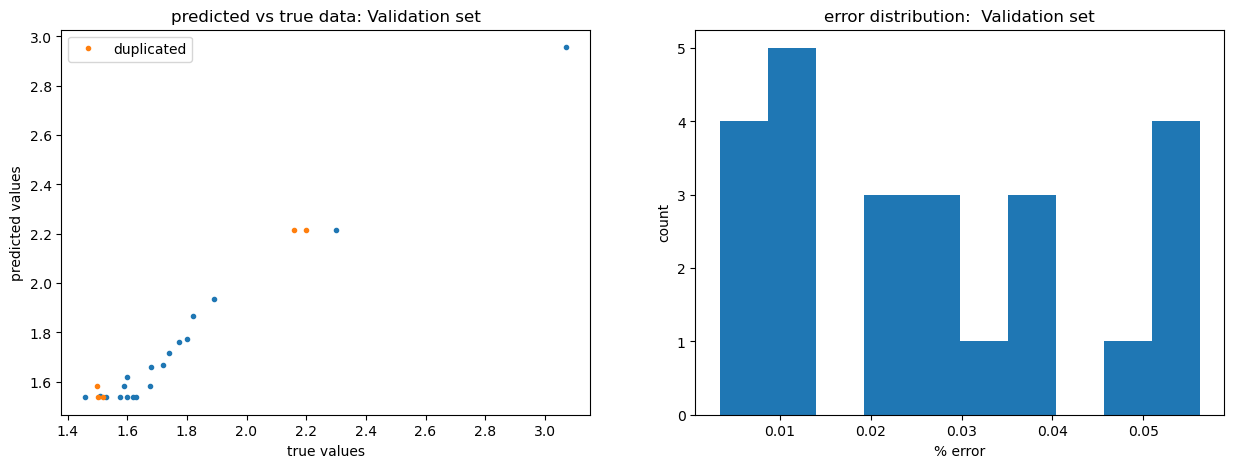

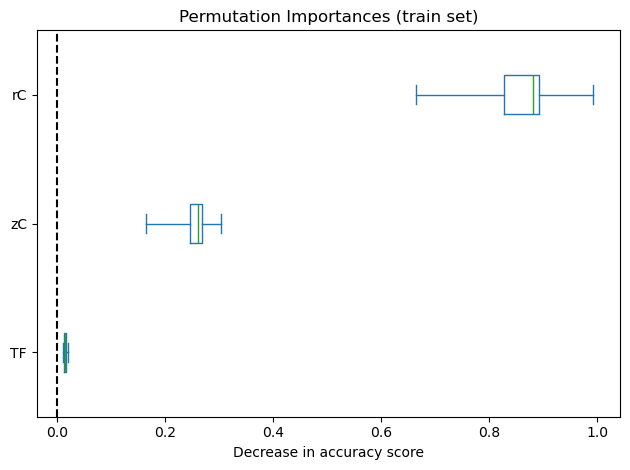

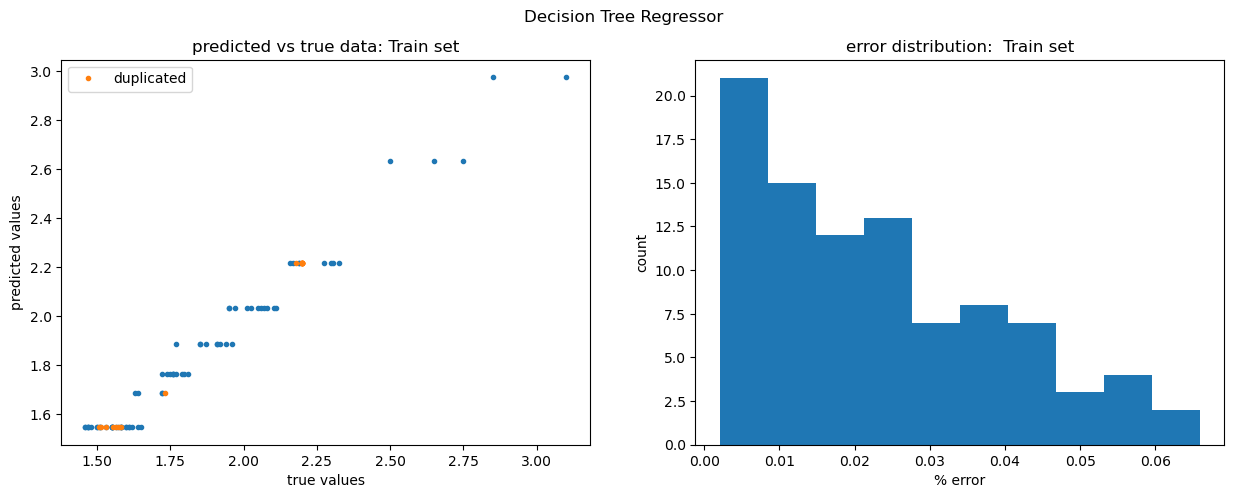

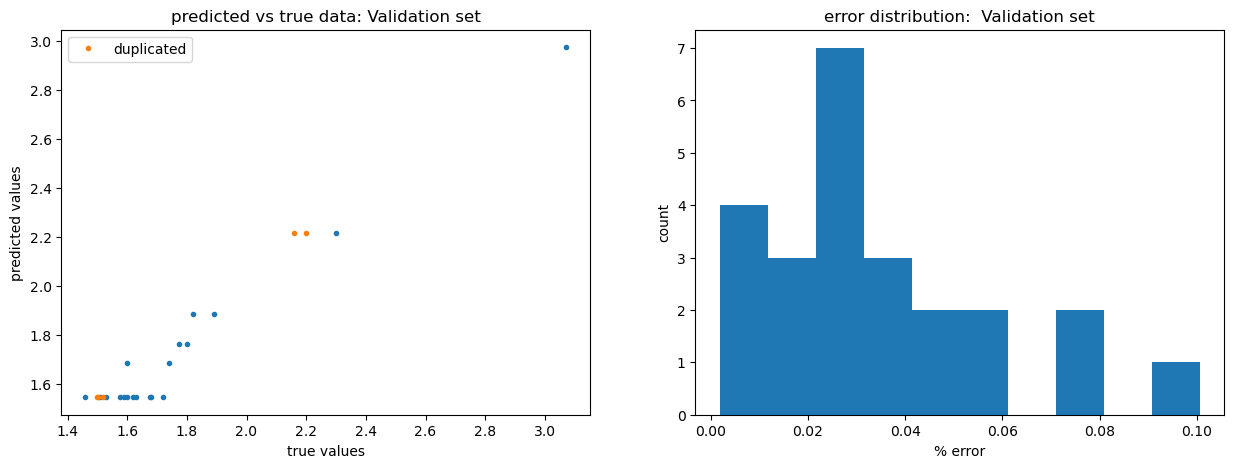

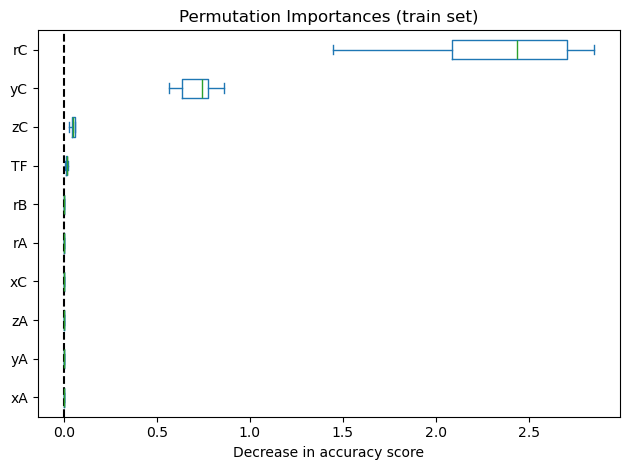

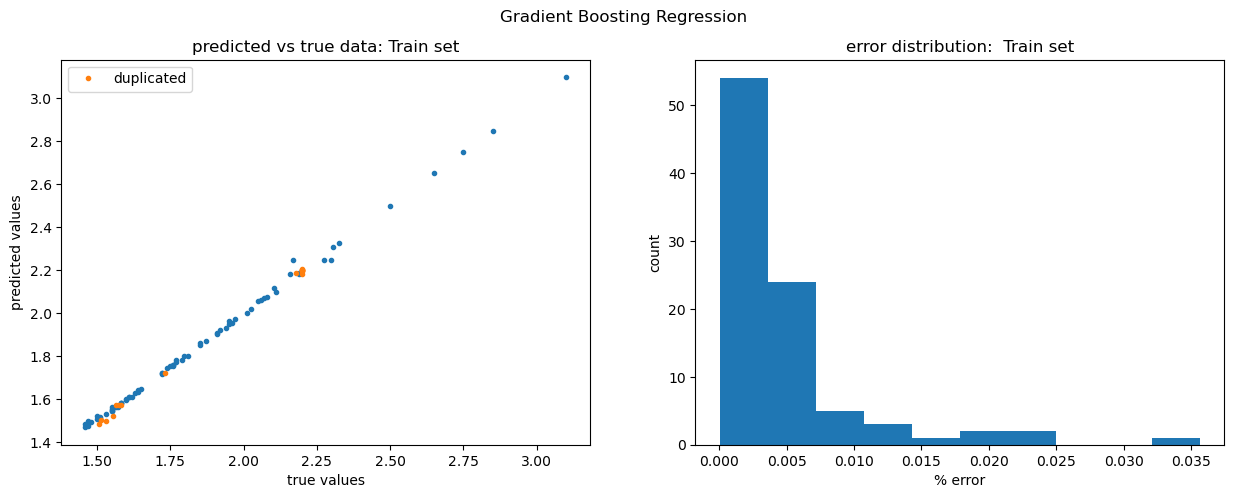

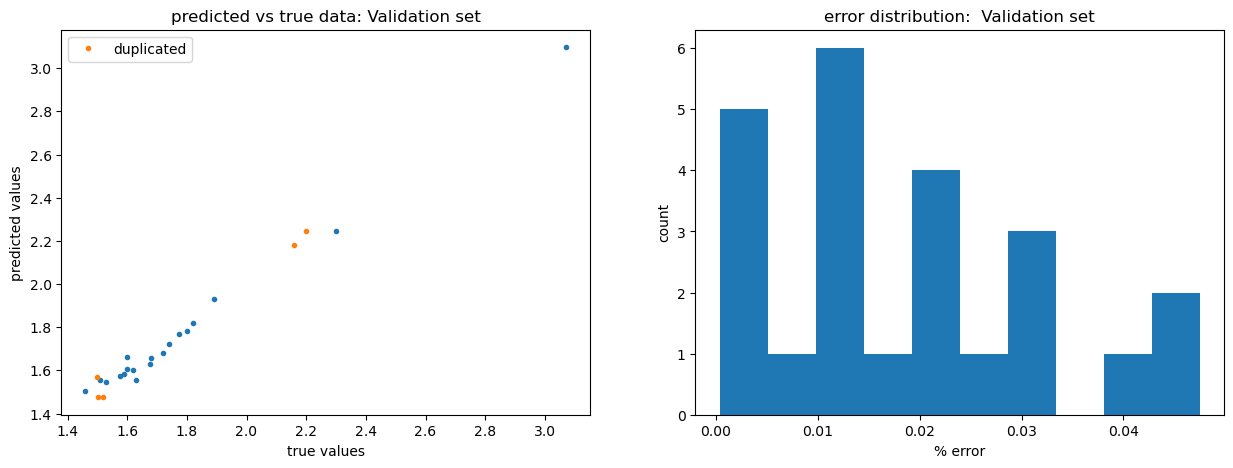

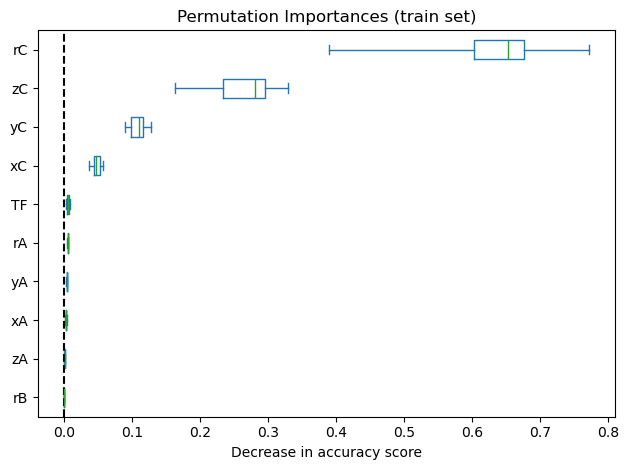

In [11]:
for name, model in models:
    model_dir = os.path.join(output_dir, name.replace(' ', '_'))
    if not os.path.exists(model_dir):
        os.makedirs(model_dir)

    if name == "Random Forest Regression1":
        X_train = X_train_b[["zC", "rC","TF"]]
        X_test = X_test_b[["zC", "rC","TF"]]
    else:
        X_train = X_train_b
        X_test = X_test_b

    model.fit(X_train, y_train)

    ytr_pred = model.predict(X_train)
    y_pred = model.predict(X_test)
    df.loc[y_test.index, "predicted"]=y_pred
    df.loc[y_test.index, "test"]=1
    df.loc[y_train.index, "predicted"]=ytr_pred
    df["error"]=abs(df["Eg"]-df["predicted"])/df["Eg"]

    print("Performance of  {}".format(name))
    print("Mean error for train set: {}".format(df[df["test"]!=1]["error"].mean()))
    print("Median error for train set: {}".format(df[df["test"]!=1]["error"].median()))
    print("Mean error for validation set: {}".format(df[df["test"]==1]["error"].mean()))
    print("Median error for validation set: {}".format(df[df["test"]==1]["error"].median()))
    error_dict = {
        "train mean error" : df[df["test"]!=1]["error"].mean(),
        "train median error" : df[df["test"]!=1]["error"].median(),
        "test mean error" : df[df["test"]==1]["error"].mean(),
        "test median error" : df[df["test"]==1]["error"].median(),
        }
    with open(os.path.join(model_dir, "performance.txt"), "w") as f:
        f.write(f"Model: {name}\n")
        f.write(json.dumps(error_dict))

    fig, ax = plt.subplots(1,2, figsize=(15, 5))
    plt.suptitle(name)
    ax[0].plot(df[(df["test"]!=1)&(df["duplicated"]!=1)]["Eg"], df[(df["test"]!=1)&(df["duplicated"]!=1)]["predicted"], ".")
    ax[0].plot(df[(df["test"]!=1)&(df["duplicated"]==1)]["Eg"], df[(df["test"]!=1)&(df["duplicated"]==1)]["predicted"], ".", label="duplicated")
    ax[0].set_xlabel("true values")
    ax[0].set_ylabel("predicted values")
    ax[0].set_title("predicted vs true data: Train set")
    ax[0].legend()
    ax[1].hist(df[df["test"]!=1]["error"])
    ax[1].set_xlabel("% error")
    ax[1].set_ylabel("count")
    ax[1].set_title("error distribution:  Train set")
    #
    plt.savefig(os.path.join(model_dir, "train_error.png"))
    ##plt.savefig(model_path+'train_error.png')
    fig, ax = plt.subplots(1,2, figsize=(15, 5))
    ax[0].plot(df[(df["test"]==1)&(df["duplicated"]!=1)]["Eg"], df[(df["test"]==1)&(df["duplicated"]!=1)]["predicted"], ".")
    ax[0].plot(df[(df["test"]==1)&(df["duplicated"]==1)]["Eg"], df[(df["test"]==1)&(df["duplicated"]==1)]["predicted"], ".", label="duplicated")
    ax[0].set_xlabel("true values")
    ax[0].set_ylabel("predicted values")
    ax[0].set_title("predicted vs true data: Validation set")
    ax[0].legend()
    ax[1].hist(df[df["test"]==1]["error"])
    ax[1].set_xlabel("% error")
    ax[1].set_ylabel("count")
    ax[1].set_title("error distribution:  Validation set")
    plt.savefig(os.path.join(model_dir, "val_error.png"))


    ##save the outliers to check the articles and their correctness
    df[df["error"]>0.1].to_csv(os.path.join(model_dir, "anomalous_points.csv"))


    result = permutation_importance(
        model, X_train, y_train, n_repeats=10, random_state=42, n_jobs=2
    )

    sorted_importances_idx = result.importances_mean.argsort()
    importances = pd.DataFrame(
        result.importances[sorted_importances_idx].T,
        columns=X_train.columns[sorted_importances_idx],
    )
    ax = importances.plot.box(vert=False, whis=10)
    ax.set_title("Permutation Importances (train set)")
    ax.axvline(x=0, color="k", linestyle="--")
    ax.set_xlabel("Decrease in accuracy score")
    ax.figure.tight_layout()
    plt.savefig(os.path.join(model_dir, "importance.png"))


    joblib.dump(model, os.path.join(model_dir, "model.joblib"))
    print(f"Model {name} is saved in dir {model_dir}")

[-2.87323773e+11  1.74056997e+10  2.47507546e+11  1.98291405e+10
  4.75023370e+08 -3.04915641e+10 -6.21896882e+11  2.18217669e+11
  1.29027448e+11  2.34043808e+01]


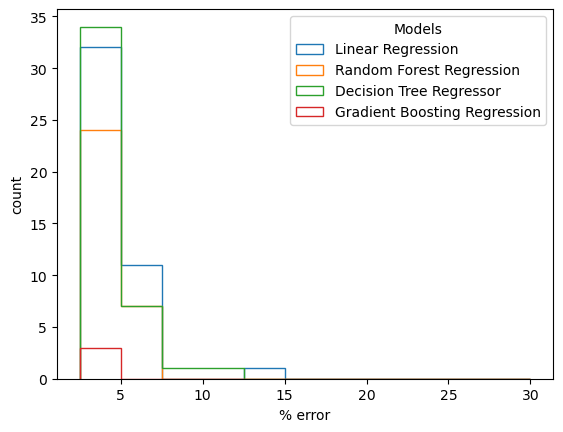

In [12]:
plt.figure()

for name, model in models:
    model_dir = os.path.join(output_dir, name.replace(' ', '_'))
    if not os.path.exists(model_dir):
        os.makedirs(model_dir)

    if name == "Random Forest Regression1":
        X_train = X_train_b[["zC", "rC", "TF"]]
        X_test = X_test_b[["zC", "rC", "TF"]]
    else:
        X_train = X
        y_train = y
        model.fit(X_train, y_train)
        if name == "Linear Regression":
            print(model.coef_)

        ytr_pred = model.predict(X_train)
        df.loc[y_train.index, "predicted"] = ytr_pred
        # Updated error calculation
        df["error"] = abs(df["Eg"] - df["predicted"]) / df["Eg"] * 100  # Multiply by 100 for percentage
        
        # Include model name in the label
        plt.hist(df["error"], histtype='step', bins=[2.5, 5, 7.5, 10, 12.5, 15, 17.5, 20, 22.5, 25, 27.5, 30], label=name)

plt.xlabel("% error")
plt.ylabel("count")
plt.legend(title="Models")  # Optional: add a title to the legend
plt.show()

Text(0, 0.5, 'predicted values')

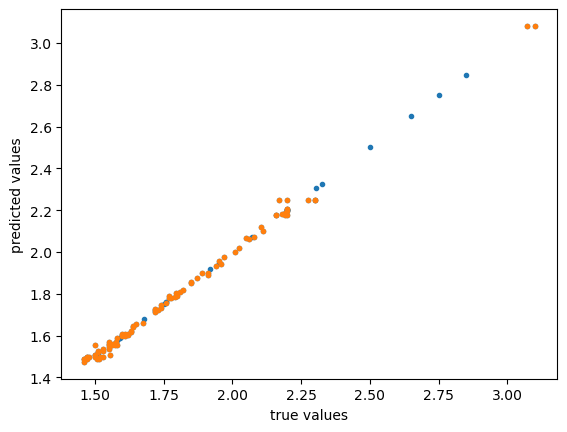

In [13]:
plt.figure()
plt.plot(df["Eg"], df["predicted"], ".")
plt.plot(df[df["error"]>0.1]["Eg"], df[df["error"]>0.1]["predicted"], ".")
plt.xlabel("true values")
plt.ylabel("predicted values")


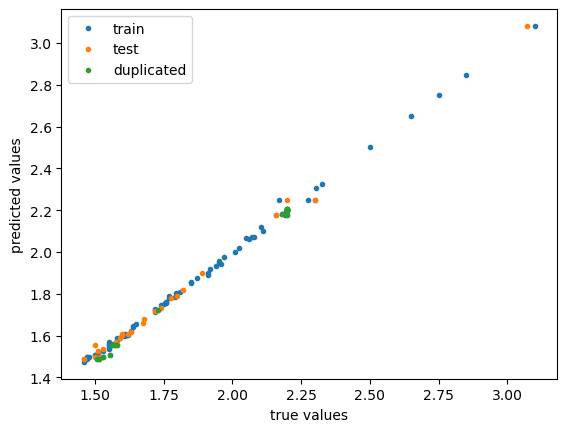

In [17]:
plt.plot(
    df[(df["test"] != 1)]["Eg"],
    df[(df["test"] != 1)]["predicted"],
    ".",
    label="train"
)
plt.plot(
    df[(df["test"] == 1)]["Eg"],
    df[(df["test"] == 1)]["predicted"],
    ".",
    label="test"
)
plt.plot(
    df[(df["test"] != 1) & (df["duplicated"] == 1)]["Eg"],
    df[(df["test"] != 1) & (df["duplicated"] == 1)]["predicted"],
    ".",
    label="duplicated"
)

plt.xlabel("true values")
plt.ylabel("predicted values")
plt.legend()
plt.show()